[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025, Petr Krysl, pkrysl@ucsd.edu

# Natural Frequency of Mass supported by a Beam on Springs

Last updated: 07/11/26

## Problem description

A simple beam is supported by two spring at the endpoints. Neglecting
the distributed mass of the beam, calculate the period of free vibration of the
beam given a concentrated mass of weight W.

The answer in the book is: T = 0.533 sec., corresponding to the frequency =
1.876 CPS.

## References

Reference: Timoshenko, S., Young, D., and Weaver, W., Vibration Problems in
Engineering, John Wiley & Sons, 4th edition, 1974. page 11, problem 1.1-3.

## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


In [21]:
from math import sqrt, pi
import context
from pystran import model
from pystran import section
from pystran import plots

US customary units, converted to inches, lbf, and lbm.


In [22]:
da = 12 * 7  # 7 ft converted to inches
db = 12 * 3  # 3 ft converted to inches
K = 300.0  # 300 lbf/in
W = 1000.0  # lbf
M = W / (12 * 32.174)  # mass in lbm
E = 3e7  # 30e6 psi
A = 1.0
I = 1.0
rho = 1e-12  # artificially reduce the mass density of the beam

In [23]:
m = model.create(2)
freedoms = m["freedoms"]

In [24]:
model.add_joint(m, 1, [0.0, 0.0])
model.add_joint(m, 2, [da, 0.0])
model.add_joint(m, 3, [da + db, 0.0])

model.add_support(m["joints"][1], freedoms.U1)
model.add_support(m["joints"][3], freedoms.U1)

The ground is represented with a joint.
The ground is immovable: all degrees of freedom are suppressed.


In [25]:
model.add_joint(m, "ground", [0.0, 0.0])
model.add_support(m["joints"]["ground"], freedoms.ALL_DOFS)

In [26]:
s2 = section.beam_2d_section("s2", E, A, I, rho)
model.add_beam_member(m, 1, [1, 2], s2)
model.add_beam_member(m, 2, [2, 3], s2)

{'mid': 2,
 'connectivity': [2, 3],
 'section': {'name': 's2',
  'E': 30000000.0,
  'rho': 1e-12,
  'CTE': 0.0,
  'A': 1.0,
  'I': 1.0}}

In [27]:
model.add_mass(m["joints"][2], freedoms.U1, M)
model.add_mass(m["joints"][2], freedoms.U2, M)

In the vertical direction, the spring stiffness is `K`. A spring is added at
either end of the beam.


In [28]:
ss = section.spring_section("ss", "extension", [0, 1], K)
model.add_spring_member(m, 1, [1, "ground"], ss)
model.add_spring_member(m, 2, [3, "ground"], ss)

{'mid': 2,
 'connectivity': [3, 'ground'],
 'section': {'name': 'ss',
  'kind': 'extension',
  'direction': [0, 1],
  'stiffness_coefficient': 300.0},
 'dofkind': (0, 1)}

Now we are ready to solve the free vibration problem.

In [29]:
model.number_dofs(m)
model.solve_free_vibration(m)

The expected frequency is 1.876 CPS, hence the vibration period is 0.533 sec.


Mode 0: f = 1.875818 Hz, T = 0.533101 sec


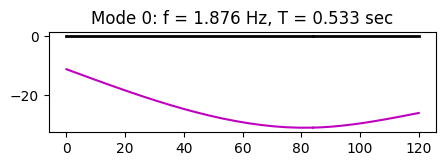

In [30]:
for mode in range(1):
    plots.setup(m)
    plots.plot_members(m)
    model.set_solution(m, m["eigvecs"][:, mode])
    ax = plots.plot_deformations(m, 50.0)
    print(
        f"Mode {mode}: f = {sqrt(m['eigvals'][mode])/2/pi:.6f} Hz, T = {2*pi/sqrt(m['eigvals'][mode]):.6f} sec"
    )
    ax.set_title(
        f"Mode {mode}: f = {sqrt(m['eigvals'][mode])/2/pi:.3f} Hz, T = {2*pi/sqrt(m['eigvals'][mode]):.3f} sec"
    )
    plots.show(m)

## Conclusions

This is really simple vibration problem, but it is valuable precisely because it is simple: there is an analogical solution and we can compare with it.